In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator
import statistics as st
from datetime import datetime
import cartopy.crs as crs
import geopandas as gpd
import matplotlib.patches as mpatches
import cartopy.feature as cfeature
import matplotlib.image as mpimg
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib as mpl

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

FONTSIZE = 18  # choose once

mpl.rcParams.update(
    {
        "font.size": FONTSIZE,
        "axes.titlesize": FONTSIZE,
        "axes.labelsize": FONTSIZE,
        "xtick.labelsize": FONTSIZE,
        "ytick.labelsize": FONTSIZE,
        "legend.fontsize": FONTSIZE,
    }
)

In [2]:
metvar = "tp"

In [3]:
nysm_radios = pd.read_csv(
    "/home/aevans/nwp_bias/src/machine_learning/notebooks/data/radiometer_network_nysm_stations.csv"
)
stations = nysm_radios["stid"].unique()
stations = [
    s
    for s in stations
    if s not in ["HFAL", "BUFF", "BELL", "ELLE", "TANN", "WARW", "MANH"]
]

In [4]:
main_path = "/home/aevans/nwp_bias/src/machine_learning/data/hybrid_output"
lstm_path = "/home/aevans/nwp_bias/src/machine_learning/data/bnn_hybrid_compare"

In [5]:
def rmse_(df):
    df = df.rename(columns={"target_error_lead_0": "target_error"})
    df.fillna(0, inplace=True)
    df["rmse"] = root_mean_squared_error(df["target_error"], df["Model forecast"])
    return df

In [6]:
hybrid_master = []
lstm_master = []
pers_master = []


dirs = [d for d in os.listdir(main_path) if d in stations]

for d in dirs:
    for fh in np.arange(1, 19):
        """
        Hybrid
        """
        temp_ = pd.read_parquet(
            f"{main_path}/{d}/{d}_fh{fh}_{metvar}_HRRR_ml_output_linear_hybrid.parquet"
        )
        temp_["station"] = d
        temp_["fh"] = fh
        temp_ = rmse_(temp_)
        hybrid_master.append(temp_)

        """LSTM"""
        temp_ = pd.read_parquet(
            f"{lstm_path}/{d}/{d}_{metvar}_{fh}_lstm_output.parquet"
        )
        temp_["station"] = d
        temp_["fh"] = fh
        temp_ = rmse_(temp_)
        lstm_master.append(temp_)

        """Persistence"""
        temp_ = pd.read_parquet(
            f"{main_path}/{d}/{d}_fh{fh}_{metvar}_HRRR_ml_output_og_hybrid.parquet"
        )
        temp_["station"] = d
        temp_["fh"] = fh
        temp_["Model forecast"] = 0.0
        temp_ = rmse_(temp_)
        pers_master.append(temp_)


# ls --> dataframes
hybrid_mse = (
    pd.concat(hybrid_master, ignore_index=True)
    .sort_values(["station", "fh"])
    .reset_index(drop=True)
)

lstm_mse = (
    pd.concat(lstm_master, ignore_index=True)
    .sort_values(["station", "fh"])
    .reset_index(drop=True)
)

pers_mse = (
    pd.concat(pers_master, ignore_index=True)
    .sort_values(["station", "fh"])
    .reset_index(drop=True)
)

In [7]:
hybrid_mse.head()

,target_error,Model forecast,diff,valid_time,station,fh,rmse
0,0.0,-0.003426,-0.013873,2024-01-01 01:00:00,BING,1,0.702527
1,0.0,-0.004549,-0.010950,2024-01-01 02:00:00,BING,1,0.702527
2,0.0,-0.007561,-0.003106,2024-01-01 03:00:00,BING,1,0.702527
3,0.0,-0.008620,-0.000349,2024-01-01 04:00:00,BING,1,0.702527
4,0.0,-0.009418,0.001729,2024-01-01 05:00:00,BING,1,0.702527


In [8]:
lstm_mse.head()

,target_error,Model forecast,valid_time,station,fh,rmse
0,0.741658,0.0,2023-01-01 01:00:00,BING,1,1.348604
1,0.046318,0.0,2023-01-08 01:00:00,BING,1,1.348604
2,0.046318,0.0,2023-01-08 02:00:00,BING,1,1.348604
3,0.046318,0.0,2023-01-08 03:00:00,BING,1,1.348604
4,0.046318,0.0,2023-01-08 04:00:00,BING,1,1.348604


In [9]:
pers_mse.head()

,target_error,Model forecast,valid_time,station,fh,rmse
0,0.045533,0.0,2018-01-01 01:00:00,BING,1,1.000561
1,0.046764,0.0,2018-01-01 02:00:00,BING,1,1.000561
2,0.045533,0.0,2018-01-01 03:00:00,BING,1,1.000561
3,0.045533,0.0,2018-01-01 04:00:00,BING,1,1.000561
4,0.045533,0.0,2018-01-01 05:00:00,BING,1,1.000561


# plot mse and r^2

In [10]:
stations = sorted(
    set(hybrid_mse["station"]) | set(lstm_mse["station"]) | set(pers_mse["station"])
)

cmap = plt.cm.tab20
station_colors = {station: cmap(i % cmap.N) for i, station in enumerate(stations)}

In [11]:
def plot_station_skill_3panel(
    hybrid_df, lstm_df, pers_df, fh_range=(1, 19), figsize=(14, 12), cmap=plt.cm.tab20
):
    """
    Create a 3-panel figure showing MSE (circles) and R^2 (x's)
    vs forecast hour for each station, with consistent colors
    across Hybrid, LSTM, and Persistence models.

    Expected columns in each DataFrame:
        ['station', 'fh', 'mse', 'r2']
    """

    # ------------------------------------------------------------------
    # Build consistent station → color mapping
    # ------------------------------------------------------------------
    stations = sorted(
        set(hybrid_df["station"]) | set(lstm_df["station"]) | set(pers_df["station"])
    )

    station_colors = {station: cmap(i % cmap.N) for i, station in enumerate(stations)}

    # ------------------------------------------------------------------
    # Internal plotting helper
    # ------------------------------------------------------------------
    def _plot_model(ax, df, title, ymin, ymax):
        # ax_r2 = ax.twinx()

        for station in stations:
            sub = df[df["station"] == station].sort_values("fh")
            if sub.empty:
                continue

            color = station_colors[station]

            # MSE → circles
            ax.plot(
                sub["fh"],
                sub["rmse"],
                color=color,
                marker="o",
                linewidth=1.5,
                markersize=5,
                alpha=0.85,
            )

            # R^2 → x's
            # ax_r2.scatter(
            #     sub["fh"], sub["r2"], color=color, marker="x", s=40, alpha=0.85
            # )

        ax.set_title(title)
        ax.set_ylabel("RMSE")
        # ax_r2.set_ylabel(r"$R^2$")
        ax.set_xlim(int(fh_range[0]) - 0.5, int(fh_range[1]))
        ax.set_ylim(ymin, ymax)
        ax.grid(True, alpha=0.3)

    # ------------------------------------------------------------------
    # Create figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=figsize, sharex=True)

    _plot_model(axes[0], hybrid_df, "Hybrid Model Performance", 0, 6.5)
    _plot_model(axes[1], lstm_df, "LSTM Model Performance", 0, 6.5)
    _plot_model(axes[2], pers_df, "Persistence Model Performance", 0, 6.5)

    axes[-1].set_xlabel("Forecast Hour")
    axes[-1].xaxis.set_major_locator(MaxNLocator(integer=True))

    # ------------------------------------------------------------------
    # Shared legend (station colors only)
    # ------------------------------------------------------------------
    legend_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=station_colors[s], label=s)
        for s in stations
    ]

    fig.legend(
        legend_handles,
        stations,
        loc="upper right",
        bbox_to_anchor=(1.25, 0.9),
        ncol=min(len(stations), 2),
        frameon=False,
        fontsize=FONTSIZE,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

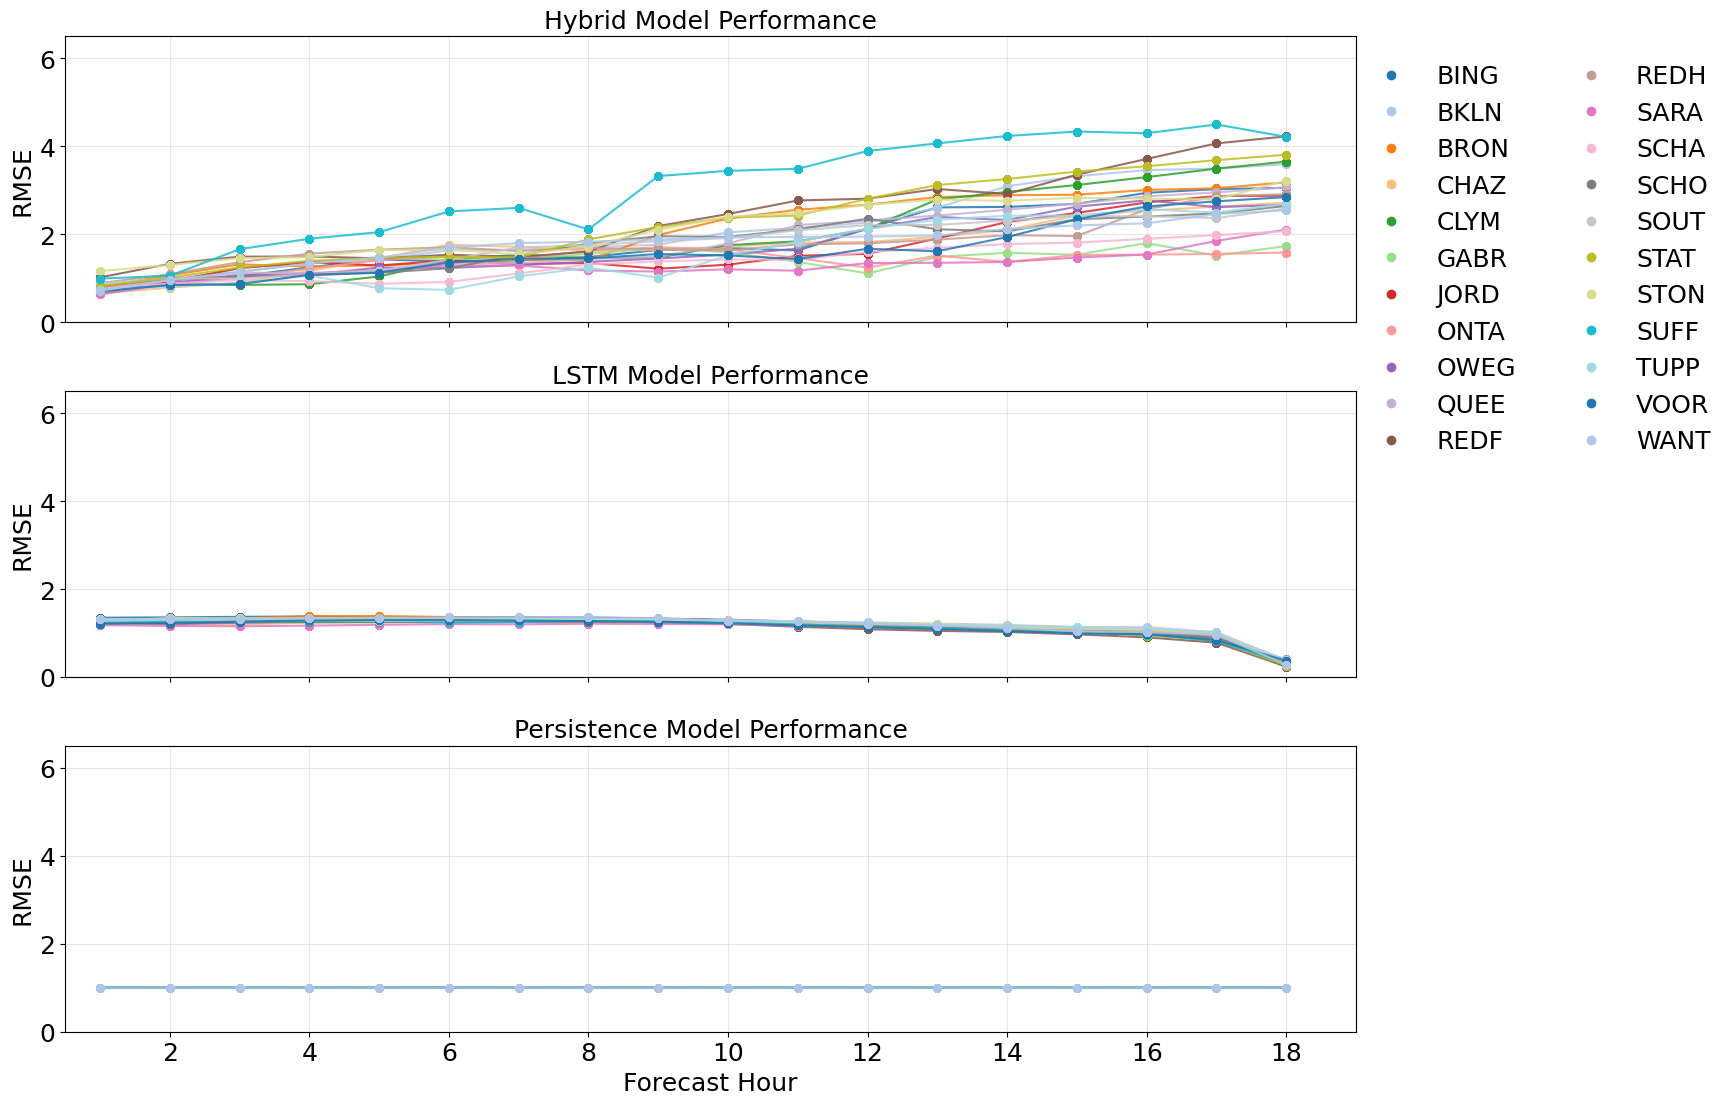

In [12]:
plot_station_skill_3panel(hybrid_mse, lstm_mse, pers_mse)

# weatherBench

In [13]:
def weatherBench_percent(
    pers_df,
    hybrid_df,
    fh_range=(1, 18),
    figsize=(18, 21),
    diverging_cmap="RdBu",
    grey_cmap="Greys",
):
    """
    Seaborn-based 2-panel heatmap figure:
      1) HRRR / Persistence MSE (greys)
      2) Hybrid % improvement vs HRRR (blue-red)

    Expected columns: ['station', 'fh', 'mse']
    """

    # --------------------------------------------------------------
    # Pivot to station x forecast-hour matrices
    # --------------------------------------------------------------
    def pivot(df):
        return (
            df.pivot(index="station", columns="fh", values="rmse")
            .sort_index()
            .loc[:, fh_range[0] : fh_range[1]]
        )

    pers_mse = pivot(pers_df)
    hybrid_mse = pivot(hybrid_df)
    pers_mse_mean = pers_mse.mean(axis=0).to_frame(name="HRRR RMSE").T
    hybrid_mse_mean = hybrid_mse.mean(axis=0).to_frame(name="All Stations").T

    # --------------------------------------------------------------
    # Percent improvement relative to HRRR
    # --------------------------------------------------------------
    hybrid_imp = 100 * (pers_mse - hybrid_mse) / pers_mse
    hybrid_imp_mean = hybrid_imp.mean(axis=0).to_frame(name="All Stations").T

    hybrid_imp = pd.concat([hybrid_imp, hybrid_imp_mean])

    vmax = np.nanmax(np.abs(hybrid_imp.values))

    # --------------------------------------------------------------
    # Plot
    # --------------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [1, 10]},
    )

    # ---------------- HRRR MSE ----------------
    sns.heatmap(
        pers_mse_mean,
        ax=axes[0],
        cmap=grey_cmap,
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "RMSE"},
        linewidths=0.3,
        linecolor="white",
    )

    axes[0].set_title("HRRR (Persistence) RMSE")
    axes[0].set_ylabel(" ")
    axes[0].set_xlabel("")

    # ---------------- Hybrid Improvement ----------------
    sns.heatmap(
        hybrid_imp,
        ax=axes[1],
        cmap=diverging_cmap,
        center=0,
        vmin=-100,
        vmax=100,
        annot=True,
        fmt=".1f",
        cbar_kws={"label": "← Worse | % Improvement vs HRRR | Better →"},
        linewidths=0.3,
        linecolor="white",
    )

    axes[1].set_title("LSTM % Improvement vs HRRR")
    axes[1].set_ylabel("Station")
    axes[1].set_xlabel("Forecast Hour")

    # plt.title("Title")
    plt.tight_layout()
    plt.show()

In [14]:
def weatherBench_raw(
    pers_df,
    hybrid_df,
    fh_range=(1, 18),
    figsize=(18, 21),
    diverging_cmap="RdBu",
    grey_cmap="Greys",
):
    """
    Seaborn-based 2-panel heatmap figure:
      1) HRRR / Persistence MSE (greys, annotated with MSE)
      2) Hybrid MSE annotated, but colored by ΔMSE (Hybrid − HRRR)

    Expected columns: ['station', 'fh', 'mse']
    """

    # --------------------------------------------------------------
    # Pivot to station x forecast-hour matrices
    # --------------------------------------------------------------
    def pivot(df):
        return (
            df.pivot(index="station", columns="fh", values="rmse")
            .sort_index()
            .loc[:, fh_range[0] : fh_range[1]]
        )

    pers_mse = pivot(pers_df)
    hybrid_mse = pivot(hybrid_df)

    # ---- top panel: mean HRRR MSE ----
    pers_mse_mean = pers_mse.mean(axis=0).to_frame(name="HRRR RMSE").T

    # --------------------------------------------------------------
    # Bottom panel: station-level ΔMSE + All Stations row
    # --------------------------------------------------------------
    diff_mse_station = pers_mse - hybrid_mse

    diff_mse_mean = diff_mse_station.mean(axis=0).to_frame(name="All Stations").T

    hybrid_mse_mean = hybrid_mse.mean(axis=0).to_frame(name="All Stations").T

    diff_mse_plot = pd.concat([diff_mse_station, diff_mse_mean])
    hybrid_mse_plot = pd.concat([hybrid_mse, hybrid_mse_mean])

    # color scaling (optionally exclude mean row)
    vmax = np.nanmax(np.abs(diff_mse_station.values))

    # --------------------------------------------------------------
    # Plot
    # --------------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [1, 10]},
    )

    # ---------------- HRRR MSE ----------------
    sns.heatmap(
        pers_mse_mean,
        ax=axes[0],
        cmap=grey_cmap,
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "RMSE"},
        linewidths=0.3,
        linecolor="white",
    )

    axes[0].set_title("HRRR (Persistence) RMSE")
    axes[0].set_ylabel("")
    axes[0].set_xlabel("")

    # ---------------- Hybrid (annotated by MSE, colored by ΔMSE) ----------------
    sns.heatmap(
        diff_mse_plot,
        ax=axes[1],
        cmap=diverging_cmap,
        center=0,
        vmin=-3,
        vmax=3,
        annot=hybrid_mse_plot,
        fmt=".2f",
        cbar_kws={"label": r" ← Worse | $\Delta$RMSE | Better →"},
        linewidths=0.3,
        linecolor="white",
    )

    axes[1].set_title("LSTM RMSE (colored by ΔRMSE vs HRRR)")
    axes[1].set_ylabel("Station")
    axes[1].set_xlabel("Forecast Hour")

    # plt.title("Title")
    plt.tight_layout()
    plt.show()

In [15]:
weatherBench_percent(
    pers_mse,
    lstm_mse,
)

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
weatherBench_raw(
    pers_mse,
    lstm_mse,
)

In [ ]:
def weatherBench_percent_all(
    pers_df,
    hybrid_df,
    lstm_df,
    fh_range=(1, 18),
    figsize=(18, 25),
    diverging_cmap="RdBu",
    grey_cmap="Greys",
):
    """
    3-panel heatmap figure:

      Top block (attached):
        1) HRRR (Persistence) RMSE              [Greys]
        2) LSTM % improvement vs HRRR           [Blue–Red]

      Bottom block:
        3) Hybrid % improvement vs HRRR by station

    Expected columns in each DataFrame:
        ['station', 'fh', 'rmse']
    """

    # --------------------------------------------------------------
    # Pivot helper: station x forecast hour
    # --------------------------------------------------------------
    def pivot(df):
        return (
            df.pivot(index="station", columns="fh", values="rmse")
            .sort_index()
            .loc[:, fh_range[0] : fh_range[1]]
        )

    pers_mse = pivot(pers_df)
    hybrid_mse = pivot(hybrid_df)
    lstm_mse = pivot(lstm_df)

    # --------------------------------------------------------------
    # Mean RMSE (HRRR baseline)
    # --------------------------------------------------------------
    pers_mse_mean = pers_mse.mean(axis=0).to_frame(name="HRRR RMSE").T

    # --------------------------------------------------------------
    # % improvement vs HRRR
    # --------------------------------------------------------------
    lstm_imp_mean = (
        (100 * (pers_mse.mean(axis=0) - lstm_mse.mean(axis=0)) / pers_mse.mean(axis=0))
        .to_frame(name="LSTM % Improvement")
        .T
    )

    hybrid_imp = 100 * (pers_mse - hybrid_mse) / pers_mse
    hybrid_imp_mean = hybrid_imp.mean(axis=0).to_frame(name="All Stations").T
    hybrid_imp = pd.concat([hybrid_imp_mean, hybrid_imp])

    vmax = np.nanmax(np.abs(hybrid_imp.values))

    # --------------------------------------------------------------
    # Figure layout (GridSpec)
    # --------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=[20, 1],  # right column = colorbars
        height_ratios=[1, 1, 10],
        hspace=0.12,
        wspace=0.05,
    )

    ax_hrrr = fig.add_subplot(gs[0, 0])
    ax_lstm = fig.add_subplot(gs[1, 0], sharex=ax_hrrr)
    ax_hybrid = fig.add_subplot(gs[2, 0], sharex=ax_hrrr)

    cax_hrrr = fig.add_subplot(gs[0, 1])
    cax_hybrid = fig.add_subplot(gs[2, 1])

    # --------------------------------------------------------------
    # HRRR RMSE (Greys)
    # --------------------------------------------------------------
    sns.heatmap(
        pers_mse_mean,
        ax=ax_hrrr,
        cmap=grey_cmap,
        annot=True,
        fmt=".2f",
        cbar=True,
        cbar_ax=cax_hrrr,
        cbar_kws={"label": "RMSE"},
        linewidths=0.3,
        linecolor="white",
    )

    ax_hrrr.set_title("Baseline Forecast Skill")
    ax_hrrr.set_ylabel("")
    ax_hrrr.set_xlabel("")

    # --------------------------------------------------------------
    # LSTM % improvement (Blue–Red)
    # --------------------------------------------------------------
    sns.heatmap(
        lstm_imp_mean,
        ax=ax_lstm,
        cmap=diverging_cmap,
        center=0,
        vmin=-100,
        vmax=100,
        annot=True,
        fmt=".1f",
        cbar=False,
        linewidths=0.3,
        linecolor="white",
    )

    ax_lstm.set_ylabel("")
    ax_lstm.set_xlabel("")

    # Make top two row labels horizontal
    for ax in [ax_hrrr, ax_lstm]:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # --------------------------------------------------------------
    # Hybrid % improvement by station
    # --------------------------------------------------------------
    sns.heatmap(
        hybrid_imp,
        ax=ax_hybrid,
        cmap=diverging_cmap,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=True,
        fmt=".1f",
        cbar=True,
        cbar_ax=cax_hybrid,
        cbar_kws={"label": "← Worse | % Improvement vs HRRR | Better →"},
        linewidths=0.3,
        linecolor="white",
    )

    ax_hybrid.set_title("Hybrid Skill Improvement by Station")
    ax_hybrid.set_ylabel("Station")
    ax_hybrid.set_xlabel("Forecast Hour")

    # --------------------------------------------------------------
    # Cosmetic cleanup
    # --------------------------------------------------------------
    for ax in [ax_hrrr, ax_lstm]:
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

    plt.tight_layout()
    plt.show()

In [ ]:
def weatherBench_raw_all(
    pers_df,
    hybrid_df,
    lstm_df,
    fh_range=(1, 18),
    figsize=(18, 25),
    diverging_cmap="RdBu",
    grey_cmap="Greys",
):
    """
    3-panel heatmap figure (raw values):

      Top block (attached):
        1) HRRR (Persistence) mean RMSE     [Greys]
        2) LSTM mean RMSE                  [Greys]

      Bottom block:
        3) Hybrid ΔRMSE vs HRRR by station
           (colored by ΔRMSE, annotated with Hybrid RMSE)

    Expected columns: ['station', 'fh', 'rmse']
    """

    # --------------------------------------------------------------
    # Pivot helper
    # --------------------------------------------------------------
    def pivot(df):
        return (
            df.pivot(index="station", columns="fh", values="rmse")
            .sort_index()
            .loc[:, fh_range[0] : fh_range[1]]
        )

    pers_mse = pivot(pers_df)
    hybrid_mse = pivot(hybrid_df)
    lstm_mse = pivot(lstm_df)

    # --------------------------------------------------------------
    # Mean RMSE rows (top block)
    # --------------------------------------------------------------
    pers_mse_mean = pers_mse.mean(axis=0).to_frame(name="HRRR RMSE").T
    lstm_mse_mean = lstm_mse.mean(axis=0).to_frame(name="LSTM RMSE").T

    # --------------------------------------------------------------
    # Hybrid ΔRMSE vs HRRR (bottom block)
    # --------------------------------------------------------------
    diff_rmse_station = pers_mse - hybrid_mse
    diff_rmse_mean = diff_rmse_station.mean(axis=0).to_frame(name="All Stations").T

    diff_rmse_plot = pd.concat([diff_rmse_mean, diff_rmse_station])

    hybrid_mse_mean = hybrid_mse.mean(axis=0).to_frame(name="All Stations").T
    hybrid_mse_plot = pd.concat([hybrid_mse, hybrid_mse_mean])

    # vmax = np.nanmax(np.abs(diff_rmse_station.values))
    vmin = -3
    vmax = 3

    # --------------------------------------------------------------
    # Figure layout (GridSpec)
    # --------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=[20, 1],  # right column = colorbars
        height_ratios=[1, 1, 10],
        hspace=0.12,
        wspace=0.05,
    )

    ax_hrrr = fig.add_subplot(gs[0, 0])
    ax_lstm = fig.add_subplot(gs[1, 0], sharex=ax_hrrr)
    ax_hybrid = fig.add_subplot(gs[2, 0], sharex=ax_hrrr)

    cax_hrrr = fig.add_subplot(gs[0, 1])
    cax_hybrid = fig.add_subplot(gs[2, 1])

    # --------------------------------------------------------------
    # HRRR RMSE
    # --------------------------------------------------------------
    sns.heatmap(
        pers_mse_mean,
        ax=ax_hrrr,
        cmap=grey_cmap,
        annot=True,
        fmt=".2f",
        cbar=True,
        cbar_ax=cax_hrrr,
        cbar_kws={"label": "RMSE"},
        linewidths=0.3,
        linecolor="white",
    )

    ax_hrrr.set_title("Baseline Forecast RMSE")
    ax_hrrr.set_ylabel("")
    ax_hrrr.set_xlabel("")

    # --------------------------------------------------------------
    # LSTM RMSE
    # --------------------------------------------------------------

    lstm_diff_mean = (
        (pers_mse.mean(axis=0) - lstm_mse.mean(axis=0)).to_frame(name="LSTM RMSE").T
    )
    sns.heatmap(
        lstm_diff_mean,  # <-- colors come from ΔRMSE
        ax=ax_lstm,
        cmap=diverging_cmap,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=lstm_mse_mean,  # <-- text is actual RMSE
        fmt=".2f",
        cbar=False,  # shared visual language with HRRR
        linewidths=0.3,
        linecolor="white",
    )

    ax_lstm.set_ylabel("")
    ax_lstm.set_xlabel("")

    # Make top two row labels horizontal
    for ax in [ax_hrrr, ax_lstm]:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # --------------------------------------------------------------
    # Hybrid ΔRMSE (colored) + Hybrid RMSE (annotated)
    # --------------------------------------------------------------
    sns.heatmap(
        diff_rmse_plot,
        ax=ax_hybrid,
        cmap=diverging_cmap,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=hybrid_mse_plot,
        fmt=".2f",
        cbar=True,
        cbar_ax=cax_hybrid,
        cbar_kws={"label": r" ← Worse | $\Delta$RMSE | Better →"},
        linewidths=0.3,
        linecolor="white",
    )

    ax_hybrid.set_title("Hybrid RMSE (colored by ΔRMSE vs HRRR)")
    ax_hybrid.set_ylabel("Station")
    ax_hybrid.set_xlabel("Forecast Hour")

    # --------------------------------------------------------------
    # Cosmetic cleanup
    # --------------------------------------------------------------
    for ax in [ax_hrrr, ax_lstm]:
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

    plt.tight_layout()
    plt.show()

In [ ]:
weatherBench_percent_all(pers_mse, hybrid_mse, lstm_mse)

In [ ]:
weatherBench_raw_all(pers_mse, hybrid_mse, lstm_mse)

# state view MSE

In [ ]:
clims = pd.read_csv("/home/aevans/nwp_bias/src/landtype/data/nysm.csv")
clim_divs = clims["climate_division_name"].unique().tolist()

In [ ]:
error_path = "/home/aevans/nwp_bias/src/machine_learning/data/error_visuals"

error_dir = os.listdir(error_path)
error_dir = sorted(error_dir)

error_dir = [e for e in error_dir if e in clim_divs]

temp_master_ls = []
wind_master_ls = []
tp_master_ls = []

temp_df_ls = []
wind_df_ls = []
precip_df_ls = []

for d in error_dir:
    print(d)
    try:
        error_df1 = pd.read_parquet(
            f"{error_path}/{d}/{d}_tp_error_metrics_master_normalized.parquet"
        )
        error_df2 = pd.read_parquet(
            f"{error_path}/{d}/{d}_u_total_error_metrics_master_normalized.parquet"
        )
        error_df3 = pd.read_parquet(
            f"{error_path}/{d}/{d}_t2m_error_metrics_master_normalized.parquet"
        )
        # Group by forecast hour (fh) and compute the mean MAE
        mean_mae_by_fh1 = error_df1.groupby("fh")["mae"].mean().reset_index()
        mean_mae_by_fh2 = error_df2.groupby("fh")["mae"].mean().reset_index()
        mean_mae_by_fh3 = error_df3.groupby("fh")["mae"].mean().reset_index()

        temp_df_ls.append(error_df3.reset_index())
        wind_df_ls.append(error_df2.reset_index())
        precip_df_ls.append(error_df1.reset_index())

        mae1 = mean_mae_by_fh1["mae"].values
        mae2 = mean_mae_by_fh2["mae"].values
        mae3 = mean_mae_by_fh3["mae"].values

        temp_master_ls.append(mae3)
        wind_master_ls.append(mae2)
        tp_master_ls.append(mae1)
    except:
        continue

In [ ]:
if metvar == "tp":
    mae_df = pd.concat(precip_df_ls)
if metvar == "t2m":
    mae_df = pd.concat(temp_df_ls)
if metvar == "u_total":
    mae_df = pd.concat(wind_df_ls)

st.mean(mae_df["mae"])
mae_df = mae_df[mae_df["station"].isin(stations)]
grouped = mae_df.groupby("station")["mae"].mean()
grouped

In [ ]:
nysm_df = pd.read_csv("/home/aevans/nwp_bias/src/landtype/data/nysm.csv")
print(nysm_df.columns)
keys = nysm_df["stid"].values
lats = nysm_df["lat [degrees]"].values
lons = nysm_df["lon [degrees]"].values
elevs = nysm_df["elevation [m]"].values

station_coords = {k: (lat, lon) for k, lat, lon in zip(keys, lats, lons)}
# elevations = {k: e for k, e in zip(keys, elevs)}

In [ ]:
grouped_df = pd.DataFrame({"station": grouped.index, "mae": grouped.values})

# Add lat/lon from your station_coords dictionary
grouped_df["lat_lon"] = grouped_df["station"].map(station_coords)
# grouped_df["elev"] = grouped_df["station"].map(elevations)

In [ ]:
grouped_df[["lat", "lon"]] = pd.DataFrame(
    grouped_df["lat_lon"].tolist(), index=grouped_df.index
)

In [ ]:
clim_div = [
    "St. Lawrence Valley",
    "Great Lakes",
    "Northern Plateau",
    "Champlain Valley",
    "Hudson Valley",
    "Mohawk Valley",
    "Western Plateau",
    "Eastern Plateau",
    "Coastal",
    "Central Lakes",
]
# # # clim_div = sorted(clim_div)
image = "/home/aevans/nwp_bias/src/landtype/data/NCEI_logo.png"
nysm_clim = pd.read_csv("/home/aevans/nwp_bias/src/landtype/data/nysm.csv")

In [ ]:
def create_state_mae(grouped_df, clim_div=clim_div, nysm_clim=nysm_clim, logo=image):
    # Create your dataframe df_
    df_ = nysm_clim.copy()
    font_size = 22

    # Create plot
    fig = plt.figure(figsize=(24, 16))
    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=crs.LambertConformal(
            central_longitude=-75.0, standard_parallels=(49, 77)
        ),
    )

    # Load the shapefile for boundaries
    shapefile_path = "/home/aevans/nwp_bias/src/machine_learning/notebooks/data/GIS.OFFICIAL_CLIM_DIVISIONS.shp"
    gdf = gpd.read_file(shapefile_path)

    ny_state_boundaries_path = "/home/aevans/nwp_bias/src/landtype/data/State.shx"
    ny_state_boundaries_geo = gpd.read_file(ny_state_boundaries_path).to_crs(epsg=4326)

    ny_bbox = ny_state_boundaries_geo.total_bounds
    gdf_filtered = gdf.cx[ny_bbox[0] : ny_bbox[2], ny_bbox[1] : ny_bbox[3]]
    gdf_filtered = pd.concat([gdf_filtered.iloc[20:29], gdf_filtered.iloc[[32]]])

    # Create a categorical column for plotting
    gdf_filtered["category"] = np.arange(len(gdf_filtered))

    # Plot shapefile with climate divisions (remove the automatic legend)
    gdf_filtered.plot(
        ax=ax,
        transform=crs.PlateCarree(),
        column="category",
        cmap="tab10",
        alpha=0.3,
        legend=False,
    )

    # Create legend for climate divisions using the colors from the 'tab10' colormap and labels from 'clim_div'
    division_patches = [
        mpatches.Patch(
            color=plt.cm.tab10(i / len(gdf_filtered)), alpha=0.3, label=clim_div[i]
        )
        for i in range(len(gdf_filtered))
    ]

    # Add the climate divisions legend
    legend1 = ax.legend(
        handles=division_patches,
        loc="lower left",
        title="Climate Divisions",
        fontsize=font_size,
        title_fontsize=font_size,
    )
    ax.add_artist(legend1)  # Ensure the first legend is added to the plot

    # Set extent for the plot
    ax.set_extent([-80.0, -72.0, 40.0, 45.5], crs=crs.PlateCarree())

    # Add features
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linestyle=":", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), zorder=1)
    ax.gridlines(
        crs=crs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="black",
        alpha=0.5,
        linestyle="--",
    )

    # Normalize MAE for visual scaling
    mae = grouped_df["mae"].values
    min_mae, max_mae = mae.min(), mae.max()
    size_scaled = 300 + 1200 * (mae - min_mae) / (
        max_mae - min_mae
    )  # make size dynamic

    # Plot scatter points
    sc = ax.scatter(
        grouped_df["lon"],
        grouped_df["lat"],
        s=size_scaled,
        c=grouped_df["mae"],
        cmap="gist_stern",
        edgecolor="black",
        transform=crs.PlateCarree(),
        zorder=10,
        vmin=0.0,
        vmax=1.0,
    )

    # Annotate scatter points
    for i, row in grouped_df.iterrows():
        ax.annotate(
            row["station"],
            (row["lon"], row["lat"]),
            textcoords="offset points",
            xytext=(0, 15),
            ha="center",
            fontsize=15,
            color="black",
            transform=crs.PlateCarree(),
            zorder=20,
        )

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.6)
    cbar.ax.tick_params(labelsize=font_size)
    cbar.set_label(r"MAE (°C)", fontsize=font_size)
    # (mm hr$^{-1}$) (°C)

    # Title and ticks
    plt.title(
        f"NYSM: Temperature-Error Predictions\nLSTM MAE Averaged Across Forecast-Hours",
        fontsize=font_size,
    )
    ax.tick_params(axis="x", labelsize=font_size)
    ax.tick_params(axis="y", labelsize=font_size)

    plt.tight_layout()
    plt.show()

In [ ]:
create_state_mae(grouped_df)

# Time of day/year

In [ ]:
def plot_combined_heatmap_day(
    clim_div,
    base_path,
    hrrr_file="ALL_u_total_hourly_abs_error_hrrr.csv",
    pers_file="ALL_u_total_hourly_abs_error_persistence.csv",
    lstm_file="ALL_u_total_hourly_error.csv",
    title="Combined Error Heatmap",
):
    def load_and_pivot(file):
        all_data = []
        for div in clim_div:
            csv_path = os.path.join(base_path, div, file)
            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                df["Hour"] = df["Hour"].str.slice(0, 2).astype(int)
                df.rename(columns={"Mean_Absolute_Error": "error"}, inplace=True)
                df["Division"] = div
                all_data.append(df)
            else:
                print(f"Missing file: {csv_path}")

        df_all = pd.concat(all_data, ignore_index=True)

        heat = df_all.pivot_table(
            index="Division", columns="Hour", values="error", aggfunc="mean"
        )
        return heat.loc[clim_div]

    # Load
    hrrr_heat = load_and_pivot(hrrr_file)
    pers_heat = load_and_pivot(pers_file)
    lstm_heat = load_and_pivot(lstm_file)

    station_counts = (
        nysm_df.groupby("climate_division_name")["stid"].nunique().to_dict()
    )

    # Build rows
    weights = np.array([station_counts[div] for div in clim_div])
    weights = weights / weights.sum()  # normalize to sum to 1

    # Weighted averages
    hrrr_row = np.average(hrrr_heat, axis=0, weights=weights)
    pers_row = np.average(pers_heat, axis=0, weights=weights)
    lstm_row = np.average(lstm_heat, axis=0, weights=weights)

    # Convert back to Series for consistent indexing
    hrrr_row = pd.Series(hrrr_row, index=hrrr_heat.columns)
    pers_row = pd.Series(pers_row, index=pers_heat.columns)
    lstm_row = pd.Series(lstm_row, index=lstm_heat.columns)

    diff_lstm_row = hrrr_row - pers_row
    diff_lstm_row_perc = (diff_lstm_row / hrrr_row) * 100

    top = pd.DataFrame(
        [hrrr_row, pers_row, diff_lstm_row_perc],
        index=["HRRR (MAE)", "LSTM (MAE)", "LSTM % Improvement"],
    )

    # Add name to LSTM row
    lstm_row.name = "All Stations"

    # Build final table
    final = pd.concat([top, lstm_heat, lstm_row.to_frame().T], axis=0)

    ##################################################################
    # SINGLE HEATMAP TRICK: we mask each row group for different cmap
    ##################################################################

    mask_grey = np.ones_like(final, dtype=bool)  # Row 0
    mask_row2 = np.ones_like(final, dtype=bool)  # Row 1 (unique cmap)
    mask_diff = np.ones_like(final, dtype=bool)  # Row 2 (difference)
    mask_main = np.ones_like(final, dtype=bool)  # Rows 3+

    mask_grey[0] = False  # Only row 0
    mask_row2[1] = False  # Only row 1
    mask_diff[2] = False  # Only row 2
    mask_main[3:] = False  # All remaining

    fig, ax = plt.subplots(figsize=(26, 12))

    # -------------------------------------------------------------
    # 1. MAIN PiYG heatmap (bottom layer)
    # -------------------------------------------------------------
    hm_main = sns.heatmap(
        final,
        cmap="PiYG",
        mask=mask_main,
        linewidths=0.4,
        ax=ax,
        cbar=False,
        vmin=-1,
        vmax=1,
    )

    # Grab the *correct* PiYG QuadMesh
    quad_piyg = hm_main.collections[0]
    # -------------------------------------------------------------
    # 4. RIGHT PiYG colorbar (main errors)
    # -------------------------------------------------------------
    cbar_right = plt.colorbar(quad_piyg, ax=ax, location="right", pad=0.02, shrink=0.75)
    cbar_right.set_label(r"Mean Error (m s$^{-1}$)", fontsize=16)

    # (m s$^{-1}$)
    # (°C)
    # -------------------------------------------------------------
    # 2. GREYS top row
    # -------------------------------------------------------------
    # Extract only the visible values in the GREYS row
    grey_values = final.iloc[0][~mask_grey[0]]

    # Compute dynamic bounds
    vmin_grey = grey_values.min()
    vmax_grey = grey_values.max()

    sns.heatmap(
        final,
        cmap="Greys",
        mask=mask_grey,
        ax=ax,
        cbar=False,
        vmin=vmin_grey,
        vmax=vmax_grey,
    )

    # -------------------------------------------------------------
    # 2B. ROW 1: Persistence values, but colored using % difference
    # -------------------------------------------------------------
    # Build temp matrix full of NaNs
    temp = final.copy() * np.nan

    # Put only diff_lstm_row into row 1 (color will come from this)
    temp.iloc[1] = diff_lstm_row.values

    # Draw heatmap for ROW 1 but colored by difference
    sns.heatmap(
        temp,
        cmap="RdBu",
        mask=mask_row2,  # mask everything except row 1
        center=0,
        ax=ax,
        cbar=False,
        vmin=-1,
        vmax=1,
    )

    # -------------------------------------------------------------
    # 3. DIFFERENCE RdBu heatmap (top of PiYG except row 0)
    # -------------------------------------------------------------
    hm_diff = sns.heatmap(
        final,
        cmap="RdBu",
        mask=mask_diff,
        center=0,
        ax=ax,
        cbar=True,
        vmin=-50,
        vmax=50,
        cbar_kws={
            "orientation": "vertical",
            "location": "left",
            "pad": 0.2,
            "label": "← Worse | % Diff. b/w Persistence and LSTM | Better →",
            "fraction": 0.01,  # shrink colorbar (smaller = shorter)
            "aspect": 30,  # optional: change thickness
        },
    )
    # >>> ADD THESE LINES <<<
    hm_diff.collections[0].colorbar.ax.tick_params(labelsize=16)
    hm_diff.collections[0].colorbar.ax.yaxis.label.set_size(16)

    # Add an emphasized line between row 2 and the rest (i.e., between row index 1 and 2)
    ax.hlines(
        y=3,  # boundary between second and third row
        xmin=0,
        xmax=final.shape[1],  # number of columns
        color="black",
        linewidth=3,
    )

    for i in range(final.shape[0]):
        for j in range(final.shape[1]):
            if not (
                mask_grey[i, j]
                and mask_row2[i, j]
                and mask_diff[i, j]
                and mask_main[i, j]
            ):
                val = final.values[i, j]
                if pd.notna(val):
                    # --------------------------------------------------
                    # Choose correct colormap + normalization per row
                    # --------------------------------------------------
                    if i == 0:
                        cmap = plt.get_cmap("Greys")
                        norm = mcolors.Normalize(vmin=vmin_grey, vmax=vmax_grey)
                        val_for_color = val

                    elif i == 1:
                        cmap = plt.get_cmap("RdBu")
                        norm = mcolors.Normalize(vmin=-1, vmax=1)
                        val_for_color = diff_lstm_row.iloc[j]

                    elif i == 2:
                        cmap = plt.get_cmap("RdBu")
                        norm = mcolors.Normalize(vmin=-50, vmax=50)
                        val_for_color = val

                    else:
                        cmap = plt.get_cmap("PiYG")
                        norm = mcolors.Normalize(vmin=-1, vmax=1)
                        val_for_color = val

                    rgba = cmap(norm(val_for_color))
                    r, g, b = rgba[:3]

                    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                    text_color = "white" if luminance < 0.5 else "black"

                    ax.text(
                        j + 0.5,
                        i + 0.5,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=12,
                        color=text_color,
                        zorder=20,
                    )

    plt.title(title, fontsize=22)
    plt.xlabel("Local Hour of Day", fontsize=18)
    plt.ylabel("Climate Divisions", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16, rotation=0)

    plt.tight_layout()
    plt.show()

    return final

In [ ]:
final_df = plot_combined_heatmap_day(
    clim_div=clim_div,
    base_path="/home/aevans/nwp_bias/src/machine_learning/data/error_visuals/dataframes",
    title="NYSM: Temperature Error Predictions\n LSTM Error Grouped By Local Time of Day",
)

In [ ]:
def plot_combined_heatmap_month(
    clim_div,
    base_path,
    title,
    hrrr_file="ALL_tp_monthly_error_abs_hrrr.csv",
    pers_file="ALL_tp_monthly_error_abs_persistence.csv",
    lstm_file="ALL_tp_monthly_error_abs.csv",
):
    # -------------------------------------------------------------
    # FUNCTION TO LOAD EACH MODEL'S CSV AND PIVOT TO DIV x MONTH
    # -------------------------------------------------------------
    def load_and_pivot(file):
        all_data = []
        for div in clim_div:
            csv_path = os.path.join(base_path, div, file)

            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)

                # Ensure month is integer (if string)
                df["Month"] = pd.to_datetime(df["Month"], format="%B").dt.month

                df.rename(columns={"Mean_Error": "error"}, inplace=True)
                df["Division"] = div

                all_data.append(df)
            else:
                print(f"Missing file: {csv_path}")

        df_all = pd.concat(all_data, ignore_index=True)

        heat = df_all.pivot_table(
            index="Division", columns="Month", values="error", aggfunc="mean"
        )

        return heat.loc[clim_div]

    # -------------------------------------------------------------
    # LOAD HRRR, Persistence, LSTM — NOW BY MONTH
    # -------------------------------------------------------------
    hrrr_heat = load_and_pivot(hrrr_file)
    pers_heat = load_and_pivot(pers_file)
    lstm_heat = load_and_pivot(lstm_file)

    # -------------------------------------------------------------
    # STATION WEIGHTS FOR DIVISIONAL AVERAGE
    # -------------------------------------------------------------
    station_counts = (
        nysm_df.groupby("climate_division_name")["stid"].nunique().to_dict()
    )

    weights = np.array([station_counts[div] for div in clim_div])
    weights = weights / weights.sum()

    # Weighted divisional mean rows
    hrrr_row = pd.Series(
        np.average(hrrr_heat, axis=0, weights=weights), index=hrrr_heat.columns
    )
    pers_row = pd.Series(
        np.average(pers_heat, axis=0, weights=weights), index=pers_heat.columns
    )
    lstm_row = pd.Series(
        np.average(lstm_heat, axis=0, weights=weights), index=lstm_heat.columns
    )

    diff_lstm_row = hrrr_row - pers_row
    diff_lstm_row_perc = (diff_lstm_row / hrrr_row) * 100

    top = pd.DataFrame(
        [hrrr_row, pers_row, diff_lstm_row_perc],
        index=["HRRR (MAE)", "LSTM (MAE)", "LSTM % Improvement"],
    )

    lstm_row.name = "All Stations"

    # -------------------------------------------------------------
    # BUILD FINAL TABLE (2 special rows + divisions + summary row)
    # -------------------------------------------------------------
    final = pd.concat([top, lstm_heat, lstm_row.to_frame().T], axis=0)

    # -------------------------------------------------------------
    # MASKS FOR MULTI-LAYER HEATMAP
    # -------------------------------------------------------------
    mask_grey = np.ones_like(final, dtype=bool)  # Row 0
    mask_row2 = np.ones_like(final, dtype=bool)  # Row 1 (unique cmap)
    mask_diff = np.ones_like(final, dtype=bool)  # Row 2 (difference)
    mask_main = np.ones_like(final, dtype=bool)  # Rows 3+

    mask_grey[0] = False  # Only row 0
    mask_row2[1] = False  # Only row 1
    mask_diff[2] = False  # Only row 2
    mask_main[3:] = False  # All remaining

    fig, ax = plt.subplots(figsize=(26, 12))

    # -------------------------------------------------------------
    # MAIN PiYG LAYER
    # -------------------------------------------------------------
    hm_main = sns.heatmap(
        final,
        cmap="Purples",
        mask=mask_main,
        linewidths=0.4,
        ax=ax,
        cbar=False,
        vmin=0,
        vmax=12,
    )

    quad_piyg = hm_main.collections[0]

    cbar_right = plt.colorbar(quad_piyg, ax=ax, location="right", pad=0.02, shrink=0.75)
    cbar_right.set_label(r"Mean Absolute Error (mm hr$^{-1}$)", fontsize=16)

    # -------------------------------------------------------------
    # GREYS ROW – dynamic vmin/vmax
    # -------------------------------------------------------------
    grey_values = final.iloc[0][~mask_grey[0]]

    vmin_grey = grey_values.min() - 0.35
    vmax_grey = grey_values.max()

    sns.heatmap(
        final,
        cmap="Greys",
        mask=mask_grey,
        ax=ax,
        cbar=False,
        vmin=vmin_grey,
        vmax=vmax_grey,
    )

    # -------------------------------------------------------------
    # 2B. ROW 1: Persistence values, but colored using % difference
    # -------------------------------------------------------------
    # Build temp matrix full of NaNs
    temp = final.copy() * np.nan

    # Put only diff_lstm_row into row 1 (color will come from this)
    temp.iloc[1] = diff_lstm_row.values

    # Draw heatmap for ROW 1 but colored by difference
    sns.heatmap(
        temp,
        cmap="RdBu",
        mask=mask_row2,  # mask everything except row 1
        center=0,
        ax=ax,
        cbar=False,
        vmin=-1,
        vmax=1,
    )

    # -------------------------------------------------------------
    # RdBu DIFFERENCE LAYER
    # -------------------------------------------------------------
    hm_diff = sns.heatmap(
        final,
        cmap="RdBu",
        mask=mask_diff,
        center=0,
        ax=ax,
        cbar=True,
        vmin=-50,
        vmax=50,
        cbar_kws={
            "orientation": "vertical",
            "location": "left",
            "pad": 0.2,
            "label": "← Worse | % Diff. b/w Persistence and LSTM | Better →",
            "fraction": 0.01,
            "aspect": 30,
        },
    )

    hm_diff.collections[0].colorbar.ax.tick_params(labelsize=16)
    hm_diff.collections[0].colorbar.ax.yaxis.label.set_size(16)

    # -------------------------------------------------------------
    # HORIZONTAL LINE SEPARATING SPECIAL ROWS
    # -------------------------------------------------------------
    ax.hlines(y=3, xmin=0, xmax=final.shape[1], color="black", linewidth=3)

    # -------------------------------------------------------------
    # ANNOTATE CELLS
    # -------------------------------------------------------------

    for i in range(final.shape[0]):
        for j in range(final.shape[1]):
            if not (
                mask_grey[i, j]
                and mask_row2[i, j]
                and mask_diff[i, j]
                and mask_main[i, j]
            ):
                val = final.values[i, j]
                if pd.notna(val):
                    # --------------------------------------------------
                    # Choose correct colormap + normalization per row
                    # --------------------------------------------------
                    if i == 0:
                        cmap = plt.get_cmap("Greys")
                        norm = mcolors.Normalize(vmin=vmin_grey, vmax=vmax_grey)
                        val_for_color = val

                    elif i == 1:
                        cmap = plt.get_cmap("RdBu")
                        norm = mcolors.Normalize(vmin=-1, vmax=1)
                        val_for_color = diff_lstm_row.iloc[j]

                    elif i == 2:
                        cmap = plt.get_cmap("RdBu")
                        norm = mcolors.Normalize(vmin=-50, vmax=50)
                        val_for_color = val

                    else:
                        cmap = plt.get_cmap("Purples")
                        norm = mcolors.Normalize(vmin=0, vmax=12)
                        val_for_color = val

                    rgba = cmap(norm(val_for_color))
                    r, g, b = rgba[:3]

                    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                    text_color = "white" if luminance < 0.5 else "black"

                    ax.text(
                        j + 0.5,
                        i + 0.5,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=12,
                        color=text_color,
                        zorder=20,
                    )

    plt.title(title, fontsize=22)
    plt.xlabel("Month of Year", fontsize=18)
    plt.ylabel("Climate Divisions", fontsize=18)
    plt.xticks(
        ticks=np.arange(12) + 0.5,
        labels=[
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ],
        fontsize=16,
    )
    plt.yticks(fontsize=16, rotation=0)

    plt.tight_layout()
    plt.show()

    return final

In [ ]:
final_df = plot_combined_heatmap_month(
    clim_div=clim_div,
    base_path="/home/aevans/nwp_bias/src/machine_learning/src/visuals/dataframes",
    title="NYSM: Precipitation Error Predictions\n LSTM MAE Grouped By Month",
)